In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset, DataLoader
from scipy.stats import spearmanr
import shap
import os

# --- CONFIG ---
DATASET_FILE = "/content/drive/MyDrive/BWAF-Net-Training/Final_Aligned_Dataset.csv"
GRAPH_FILE = "/content/drive/MyDrive/BWAF-Net-Training/graph_data.pt"
MODEL_PATH = "/content/drive/MyDrive/BWAF-Net-Training/results_bwaf/best_bwaf_model.pth"
OUTPUT_DIR = "/content/drive/MyDrive/BWAF-Net-Training/results_xai/"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

os.makedirs(OUTPUT_DIR, exist_ok=True)

--- RUNNING COUPLED INTERPRETABILITY ANALYSIS ---

  1. GATE DISTRIBUTION

Comparison of activation levels between branches.

------------------------------
DATA TABLE:
    Gate     Mean      Std      Max   % > 0.1
Sequence 0.400168 0.145974 0.861923 99.562399
   Graph 0.032597 0.027916 0.303432  3.322528
------------------------------


/tmp/ipython-input-664707592.py:134: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Seq_Corr', y='Prior', data=corr_df, palette='Blues_r', ax=axes[0])
/tmp/ipython-input-664707592.py:141: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Graph_Corr', y='Prior', data=corr_df_graph, palette='Greens_r', ax=axes[1])



  2. COUPLED CORRELATION

This table compares how each motif correlates with Sequence vs Graph attention.

------------------------------
DATA TABLE:
    Prior  Seq_Corr  Graph_Corr
CpG_Count  0.394553   -0.558174
      BRE  0.293213   -0.526457
 CAAT_Box  0.222173   -0.270121
      Sp1 -0.040595   -0.045158
  Octamer -0.062210    0.036442
   GC_Box -0.162556   -0.222721
    E_Box -0.169921    0.065457
      RFX -0.281939    0.399309
      MRE -0.298066   -0.156382
      PPE -0.340511    0.413532
 TATA_Box -0.350573    0.204601
------------------------------
Calculating Coupled SHAP (Sequence + Graph)...


  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]


  3. COUPLED SHAP IMPORTANCE

Comparing which features drive the decision for each branch.

------------------------------
DATA TABLE:
  Feature  Seq |SHAP|  Graph |SHAP|
CpG_Count    0.104606      0.019252
   GC_Box    0.066891      0.001697
      PPE    0.051792      0.007618
 TATA_Box    0.042459      0.001998
      MRE    0.037482      0.001796
      RFX    0.030250      0.011432
      Sp1    0.011848      0.006930
      BRE    0.007946      0.005111
 CAAT_Box    0.007862      0.006288
  Octamer    0.004571      0.000094
    E_Box    0.003626      0.001089
------------------------------
✅ Analysis Complete. Results in /content/drive/MyDrive/BWAF-Net-Training/results_xai/


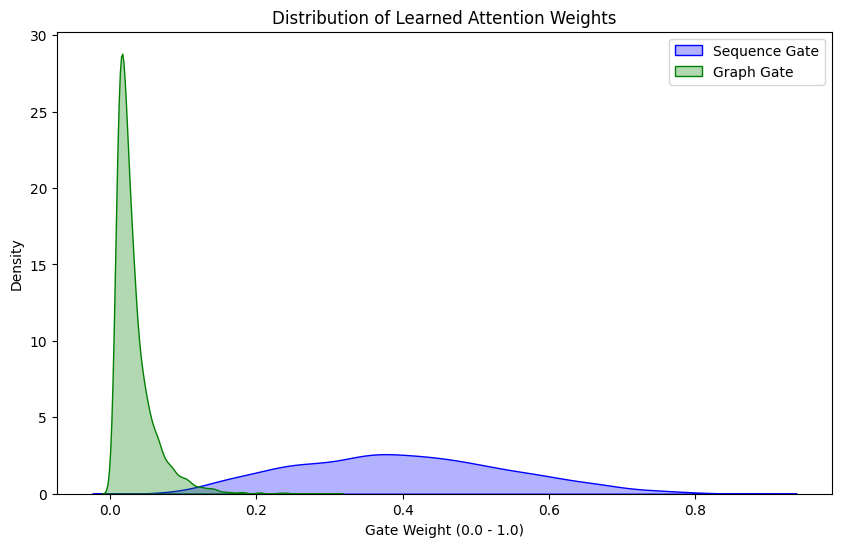

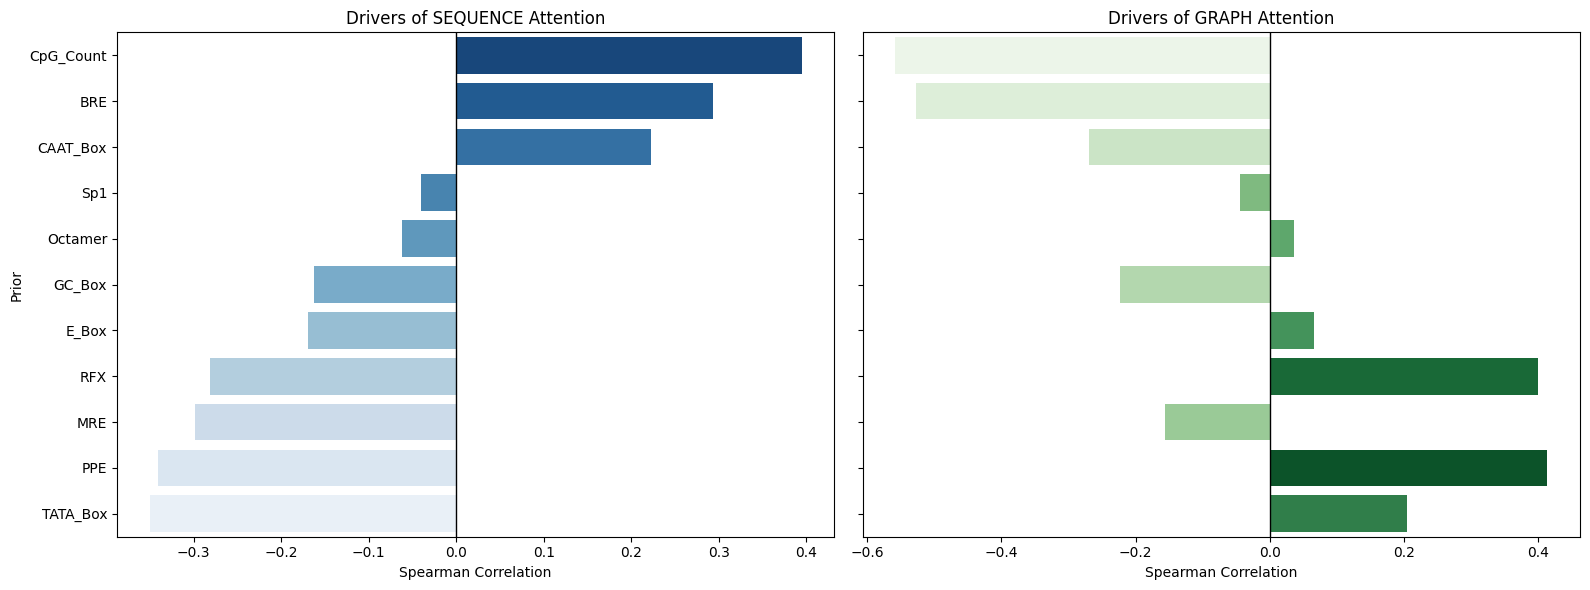

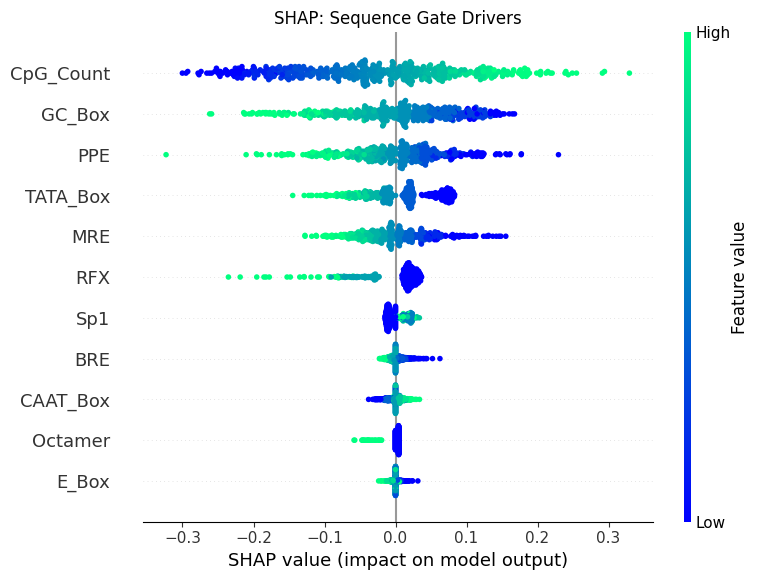

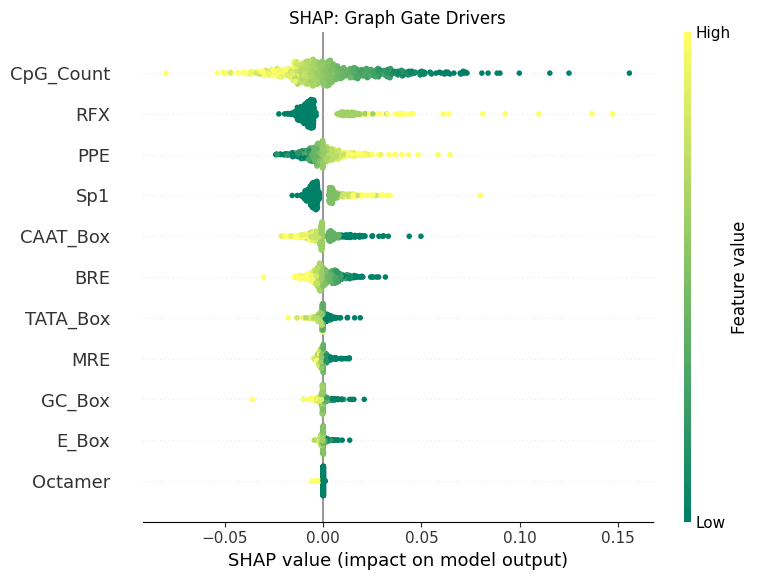

In [ ]:
# --- HELPER: PRINT BOX ---
def print_section(title, text, dataframe=None):
    print("\n" + "="*80)
    print(f"  {title.upper()}")
    print("="*80)
    print(f"\n{text}\n")
    if dataframe is not None:
        print("-" * 30)
        print("DATA TABLE:")
        print(dataframe.to_string(index=False))
        print("-" * 30)

# --- RE-DEFINE MODEL (TRANSFORMER VERSION) ---
class BWAF_Net(nn.Module):
    def __init__(self, num_genes, num_tf_features, d_model=64, prior_dim=11):
        super(BWAF_Net, self).__init__()
        self.embedding = nn.Embedding(5, d_model, padding_idx=4)
        self.pos_encoder = nn.Parameter(torch.randn(1, 2000, d_model))
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=4, batch_first=True, dim_feedforward=256)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)
        self.seq_proj = nn.Sequential(nn.Linear(d_model, d_model), nn.LayerNorm(d_model), nn.ReLU(), nn.Dropout(0.3))
        self.gat = GATConv(num_tf_features, d_model, heads=1)
        self.register_buffer('edge_index', None); self.register_buffer('node_features', None)
        self.seq_gate = nn.Sequential(nn.Linear(prior_dim, 32), nn.ReLU(), nn.Linear(32, 1), nn.Sigmoid())
        self.graph_gate = nn.Sequential(nn.Linear(prior_dim, 32), nn.ReLU(), nn.Linear(32, 1), nn.Sigmoid())
        self.classifier = nn.Sequential(nn.LayerNorm(d_model + prior_dim), nn.Linear(d_model + prior_dim, 128), nn.ReLU(), nn.Dropout(0.3), nn.Linear(128, 1))

    def set_graph_data(self, x, edge_index):
        self.edge_index = edge_index
        self.node_features = x

    def forward(self, seq, priors, gene_idx):
        pad_mask = (seq == 4)
        x_seq = self.embedding(seq) + self.pos_encoder
        x_seq = self.transformer(x_seq, src_key_padding_mask=pad_mask)
        mask = (~pad_mask).unsqueeze(-1).float()
        x_seq = (x_seq * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1)
        h_seq = self.seq_proj(x_seq)

        all_nodes = F.elu(self.gat(self.node_features, self.edge_index))
        h_graph = all_nodes[gene_idx]

        alpha_seq = self.seq_gate(priors)
        alpha_graph = self.graph_gate(priors)

        h_fused = (alpha_seq * h_seq) + (alpha_graph * h_graph)
        h_final = torch.cat([h_fused, priors], dim=1)
        return self.classifier(h_final), alpha_seq, alpha_graph

# --- DATASET ---
class GenomicDataset(Dataset):
    def __init__(self, df, gene_to_idx):
        self.seqs = df['sequence'].values
        self.labels = df['label'].values
        self.gene_idxs = [gene_to_idx.get(g, 0) for g in df['gene_id'].values]
        self.prior_names = ["TATA_Box", "CAAT_Box", "GC_Box", "BRE", "MRE", "PPE", "Octamer", "Sp1", "E_Box", "RFX", "CpG_Count"]
        self.priors = np.log1p(df[self.prior_names].values.astype(np.float32))
        self.dna_map = {'A':0, 'C':1, 'G':2, 'T':3, 'N':4}
    def __len__(self): return len(self.seqs)
    def __getitem__(self, i):
        seq = [self.dna_map.get(s, 4) for s in self.seqs[i]]
        return (torch.tensor(seq, dtype=torch.long), torch.tensor(self.priors[i], dtype=torch.float32),
                torch.tensor(self.gene_idxs[i], dtype=torch.long), torch.tensor(self.labels[i], dtype=torch.float32))

# --- ANALYSIS RUNNER ---
def run_analysis():
    print("--- RUNNING COUPLED INTERPRETABILITY ANALYSIS ---")

    # Load
    df = pd.read_csv(DATASET_FILE)
    test_df = df[df['partition'] == 'test']
    graph = torch.load(GRAPH_FILE, map_location=DEVICE)
    ds = GenomicDataset(test_df, graph['gene_to_idx'])
    loader = DataLoader(ds, batch_size=32, shuffle=False)

    model = BWAF_Net(graph['x'].shape[0], graph['x'].shape[1]).to(DEVICE)
    model.set_graph_data(graph['x'].to(DEVICE), graph['edge_index'].to(DEVICE))
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    model.eval()

    # 1. Extract Data
    alpha_seqs, alpha_graphs, all_priors = [], [], []
    all_labels = []

    with torch.no_grad():
        for seq, prior, gidx, y in loader:
            seq, prior, gidx = seq.to(DEVICE), prior.to(DEVICE), gidx.to(DEVICE)
            _, a_seq, a_graph = model(seq, prior, gidx)
            alpha_seqs.extend(a_seq.cpu().numpy().flatten())
            alpha_graphs.extend(a_graph.cpu().numpy().flatten())
            all_priors.extend(prior.cpu().numpy())
            all_labels.extend(y.numpy())

    alpha_seqs = np.array(alpha_seqs)
    alpha_graphs = np.array(alpha_graphs)
    all_priors = np.array(all_priors)

    # ---------------------------------------------------------
    # ANALYSIS 1: GATE DISTRIBUTION STATS
    # ---------------------------------------------------------
    plt.figure(figsize=(10, 6))
    sns.kdeplot(alpha_seqs, fill=True, label='Sequence Gate', color='blue', alpha=0.3)
    sns.kdeplot(alpha_graphs, fill=True, label='Graph Gate', color='green', alpha=0.3)
    plt.title("Distribution of Learned Attention Weights")
    plt.xlabel("Gate Weight (0.0 - 1.0)")
    plt.legend()
    plt.savefig(os.path.join(OUTPUT_DIR, "gate_dist_coupled.png"))

    stats = []
    for name, arr in [("Sequence", alpha_seqs), ("Graph", alpha_graphs)]:
        stats.append({
            "Gate": name, "Mean": np.mean(arr), "Std": np.std(arr),
            "Max": np.max(arr), "% > 0.1": np.mean(arr > 0.1) * 100
        })
    stats_df = pd.DataFrame(stats)
    print_section("1. Gate Distribution", "Comparison of activation levels between branches.", stats_df)

    # ---------------------------------------------------------
    # ANALYSIS 2: COUPLED CORRELATION (THE NEW PLOT)
    # ---------------------------------------------------------
    prior_names = ds.prior_names
    correlations = []
    for i, name in enumerate(prior_names):
        r_seq, _ = spearmanr(all_priors[:, i], alpha_seqs)
        r_graph, _ = spearmanr(all_priors[:, i], alpha_graphs)
        correlations.append({'Prior': name, 'Seq_Corr': r_seq, 'Graph_Corr': r_graph})

    corr_df = pd.DataFrame(correlations).sort_values('Seq_Corr', ascending=False)

    # Generate Side-by-Side Plot
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

    # Plot 1: Sequence Drivers (Blue)
    sns.barplot(x='Seq_Corr', y='Prior', data=corr_df, palette='Blues_r', ax=axes[0])
    axes[0].set_title("Drivers of SEQUENCE Attention")
    axes[0].set_xlabel("Spearman Correlation")
    axes[0].axvline(0, color='black', linewidth=1)

    # Plot 2: Graph Drivers (Green) - Sorted by Graph Corr
    corr_df_graph = corr_df.sort_values('Graph_Corr', ascending=False)
    sns.barplot(x='Graph_Corr', y='Prior', data=corr_df_graph, palette='Greens_r', ax=axes[1])
    axes[1].set_title("Drivers of GRAPH Attention")
    axes[1].set_xlabel("Spearman Correlation")
    axes[1].axvline(0, color='black', linewidth=1)

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "correlation_coupled.png"))

    print_section("2. Coupled Correlation",
                  "This table compares how each motif correlates with Sequence vs Graph attention.",
                  corr_df)

    # ---------------------------------------------------------
    # ANALYSIS 3: COUPLED SHAP (THE NEW INSIGHT)
    # ---------------------------------------------------------
    print("Calculating Coupled SHAP (Sequence + Graph)...")
    background = all_priors[:100]
    test_samples = all_priors[100:600]

    # Wrapper for Sequence
    def predict_seq(priors_np):
        priors_t = torch.tensor(priors_np, dtype=torch.float32).to(DEVICE)
        with torch.no_grad(): return model.seq_gate(priors_t).cpu().numpy().flatten()

    # Wrapper for Graph
    def predict_graph(priors_np):
        priors_t = torch.tensor(priors_np, dtype=torch.float32).to(DEVICE)
        with torch.no_grad(): return model.graph_gate(priors_t).cpu().numpy().flatten()

    # Run SHAP
    explainer_seq = shap.KernelExplainer(predict_seq, background)
    shap_seq = explainer_seq.shap_values(test_samples)

    explainer_graph = shap.KernelExplainer(predict_graph, background)
    shap_graph = explainer_graph.shap_values(test_samples)

    # Save Separate Plots (Cleaner for LaTeX)
    plt.figure()
    shap.summary_plot(shap_seq, pd.DataFrame(test_samples, columns=prior_names), show=False, cmap='winter')
    plt.title("SHAP: Sequence Gate Drivers")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "shap_seq.png"))

    plt.figure()
    shap.summary_plot(shap_graph, pd.DataFrame(test_samples, columns=prior_names), show=False, cmap='summer')
    plt.title("SHAP: Graph Gate Drivers")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "shap_graph.png"))

    # Table Comparison
    mean_shap_seq = np.abs(shap_seq).mean(axis=0)
    mean_shap_graph = np.abs(shap_graph).mean(axis=0)

    shap_table = pd.DataFrame({
        "Feature": prior_names,
        "Seq |SHAP|": mean_shap_seq,
        "Graph |SHAP|": mean_shap_graph
    }).sort_values("Seq |SHAP|", ascending=False)

    print_section("3. Coupled SHAP Importance",
                  "Comparing which features drive the decision for each branch.",
                  shap_table)

    print(f"✅ Analysis Complete. Results in {OUTPUT_DIR}")

if __name__ == "__main__":
    run_analysis()